In [23]:
# ! pip install pymining
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/Copy of transactions.csv"
df = pd.read_csv(file_path)
df

,user_id,sequence
0,1,"A,B,C,D"
1,2,"A,B,E"
2,3,"A,B,C"
3,4,"B,C,E"


# **SPADE ALGORITHM**

In [17]:
from pymining import seqmining

sequences = df["sequence"].tolist()
sequences

[['A', 'B', 'C', 'D'], ['A', 'B', 'E'], ['A', 'B', 'C'], ['B', 'C', 'E']]

In [18]:
min_support = 2

patterns = seqmining.freq_seq_enum(sequences, min_support)
patterns

{(('A',), 3),
 (('A', 'B'), 3),
 (('A', 'B', 'C'), 2),
 (('A', 'C'), 2),
 (('B',), 4),
 (('B', 'C'), 3),
 (('B', 'E'), 2),
 (('C',), 3),
 (('E',), 2)}

In [19]:
for pattern, support in sorted(patterns, key=lambda x: -x[1])[:10]:
    print(f"Pattern: {pattern}, Support: {support}")

Pattern: ('B',), Support: 4
Pattern: ('A', 'B'), Support: 3
Pattern: ('B', 'C'), Support: 3
Pattern: ('C',), Support: 3
Pattern: ('A',), Support: 3
Pattern: ('A', 'C'), Support: 2
Pattern: ('E',), Support: 2
Pattern: ('B', 'E'), Support: 2
Pattern: ('A', 'B', 'C'), Support: 2


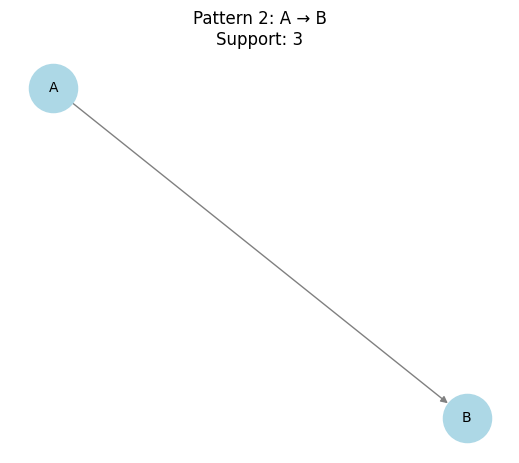

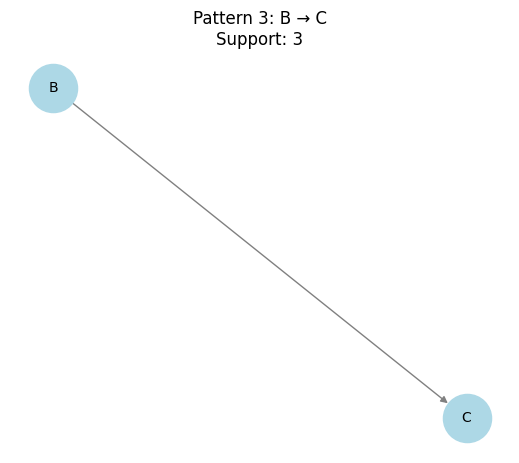

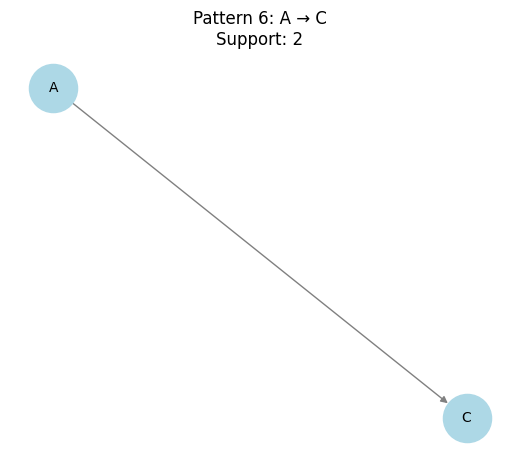

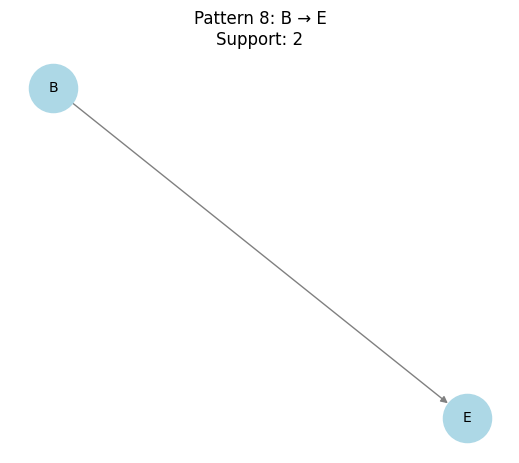

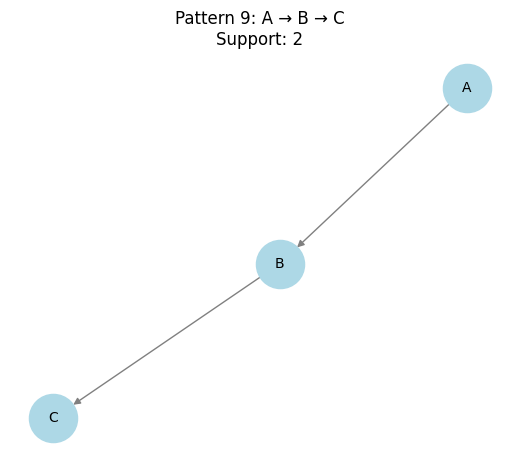

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

for idx, (pattern, support) in enumerate(sorted(patterns, key=lambda x: -x[1]), start=1):
    if len(pattern) < 2:
        continue

    G = nx.DiGraph()

    for i in range(len(pattern) - 1):
        G.add_edge(pattern[i], pattern[i + 1])

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(5, 4))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1200,
            font_size=10, arrows=True, edge_color='gray')
    plt.title(f"Pattern {idx}: {' → '.join(pattern)}\nSupport: {support}")
    plt.tight_layout()
    plt.show()

# **GSP ALGORITHM**

In [33]:
from itertools import combinations
from collections import defaultdict

sequences = df['sequence'].tolist()

In [34]:
def gsp_with_combinations(sequences, min_support=2, max_length=4):
    frequent_patterns = []

    for k in range(2, max_length + 1):
        candidate_counts = defaultdict(int)

        for seq in sequences:
            for combo in combinations(seq, k):
                candidate_counts[combo] += 1

        frequent_k = {pattern: count for pattern, count in candidate_counts.items() if count >= min_support}
        if not frequent_k:
            break

        frequent_patterns.extend(frequent_k.items())

    return frequent_patterns

In [54]:
patterns = gsp_with_combinations(sequences, min_support=2)

for idx, (pattern, support) in enumerate(sorted(patterns, key=lambda x: -x[1]), start=1):
    print(f"Pattern: {' → '.join(pattern)}, Support: {support}")

Pattern: A → B, Support: 3
Pattern: B → C, Support: 3
Pattern: A → C, Support: 2
Pattern: B → E, Support: 2
Pattern: A → B → C, Support: 2


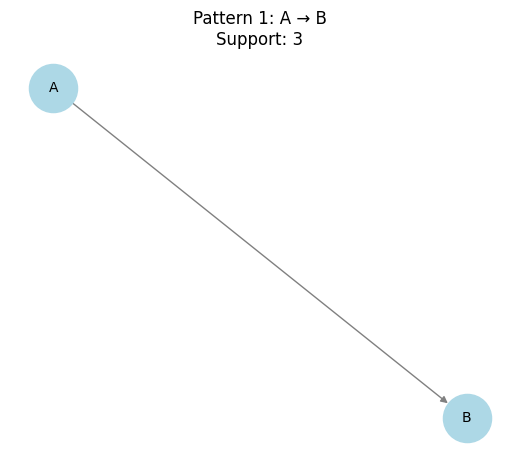

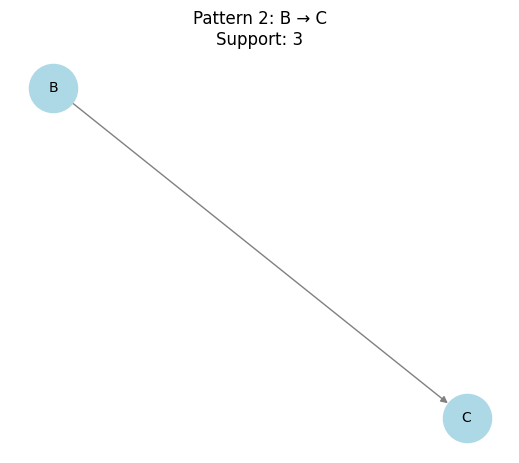

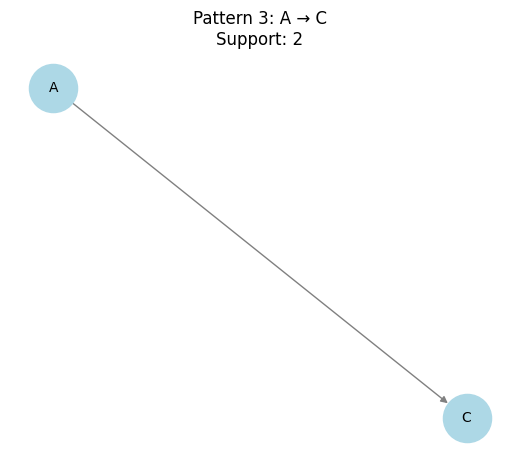

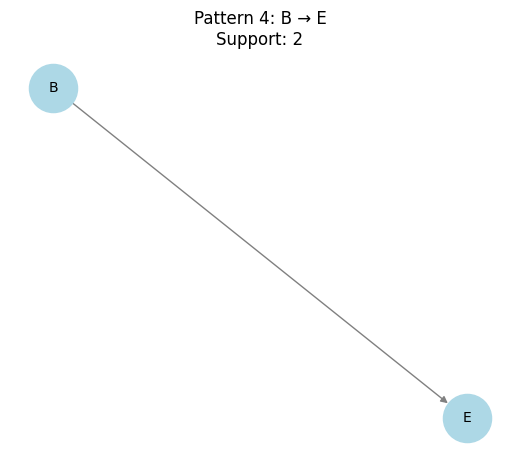

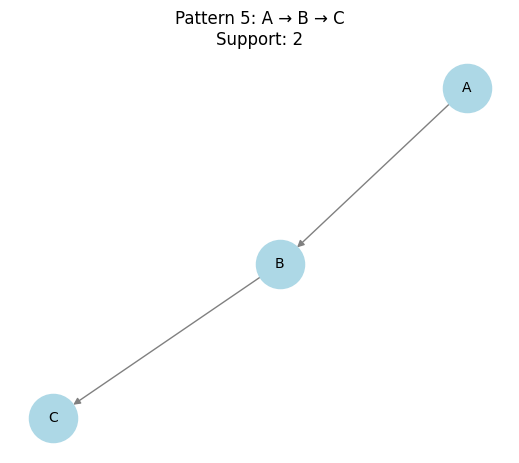

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

for idx, (pattern, support) in enumerate(sorted(patterns, key=lambda x: -x[1]), start=1):
    if len(pattern) < 2:
        continue

    G = nx.DiGraph()

    for i in range(len(pattern) - 1):
        G.add_edge(pattern[i], pattern[i + 1])

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(5, 4))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1200,
            font_size=10, arrows=True, edge_color='gray')
    plt.title(f"Pattern {idx}: {' → '.join(pattern)}\nSupport: {support}")
    plt.tight_layout()
    plt.show()

# **PREFIXSPAN ALGORITHM**

In [40]:
# !pip install prefixspan
from prefixspan import PrefixSpan

transactions = df['sequence'].tolist()
transactions

[['A', 'B', 'C', 'D'], ['A', 'B', 'E'], ['A', 'B', 'C'], ['B', 'C', 'E']]

In [48]:
ps = PrefixSpan(transactions)

patterns = ps.topk(10)
min_support = 2
filtered_patterns = [(support, seq) for support, seq in patterns if (support >= min_support) and (2 <= len(seq) <= 3)]

for i, (support, seq) in enumerate(filtered_patterns[:10], start=1):
    print(f"Pattern: {seq}, Support: {support}")

Pattern: ['A', 'B'], Support: 3
Pattern: ['B', 'C'], Support: 3
Pattern: ['A', 'B', 'C'], Support: 2
Pattern: ['A', 'C'], Support: 2
Pattern: ['B', 'E'], Support: 2


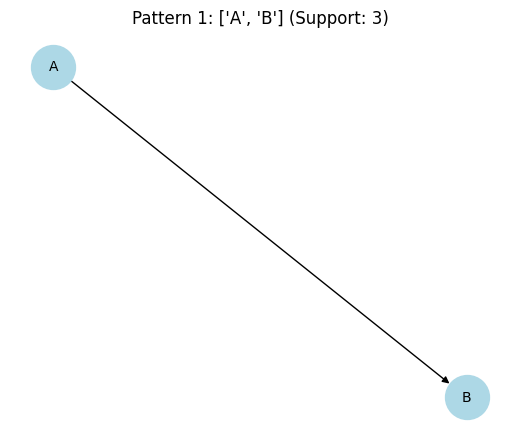

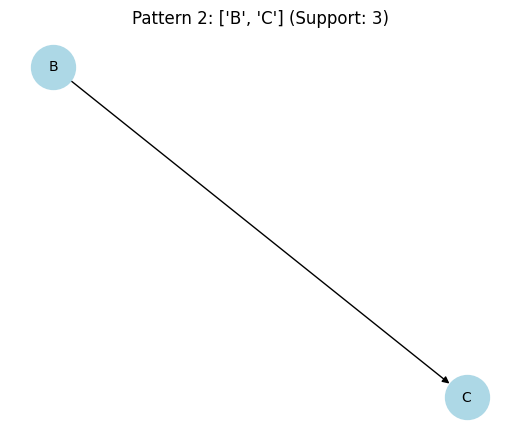

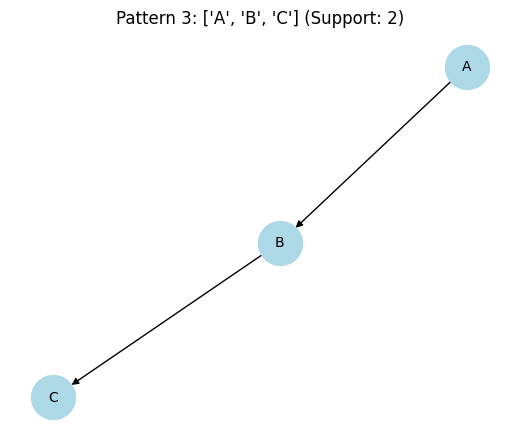

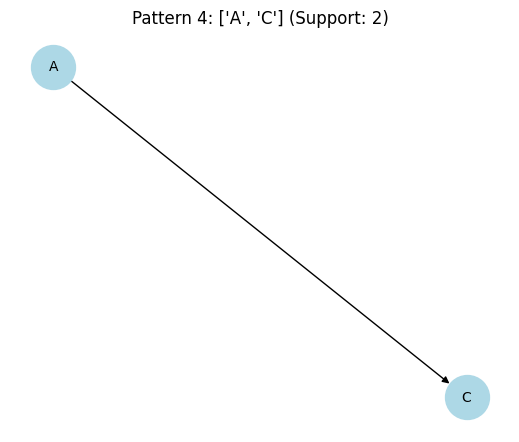

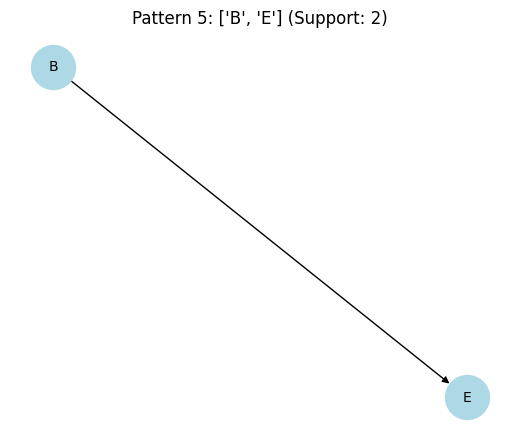

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

for idx, (support, seq) in enumerate(filtered_patterns[:10], start=1):
    G = nx.DiGraph()

    for i in range(len(seq) - 1):
        G.add_edge(seq[i], seq[i + 1])

    plt.figure(figsize=(5, 4))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=10, arrows=True)
    plt.title(f"Pattern {idx}: {seq} (Support: {support})")
    plt.show()